In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
df=pd.read_csv("C:/Users/PC/Downloads/archive (6).zip")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Figure size 600x600 with 0 Axes>

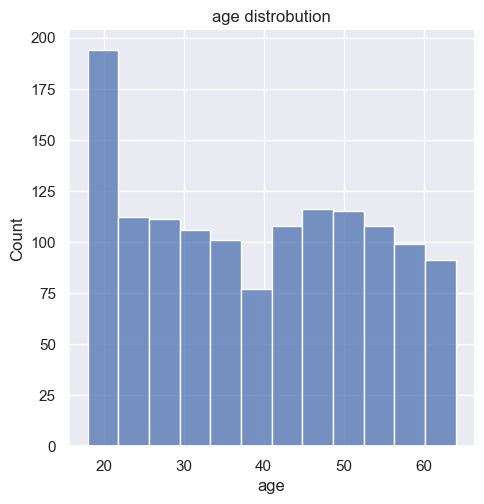

In [6]:
# distribution of age value
sns.set()
plt.figure(figsize=(6,6))
sns.displot(df['age'])
plt.title('age distrobution')
plt.show()

<Figure size 600x600 with 0 Axes>

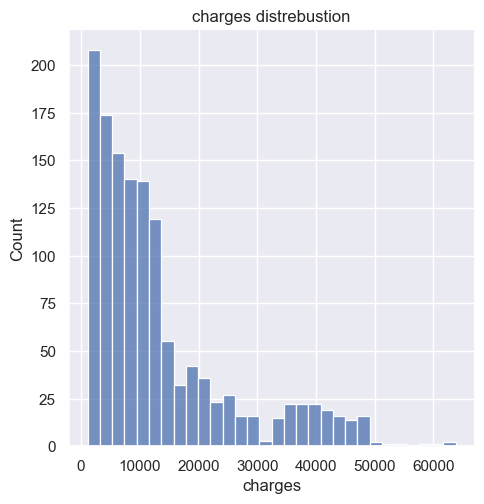

In [8]:
sns.set()
plt.figure(figsize=(6,6))
sns.displot(df['charges'])
plt.title('charges distrebustion')
plt.show()


In [9]:
df.value_counts('sex')

sex
male      676
female    662
Name: count, dtype: int64

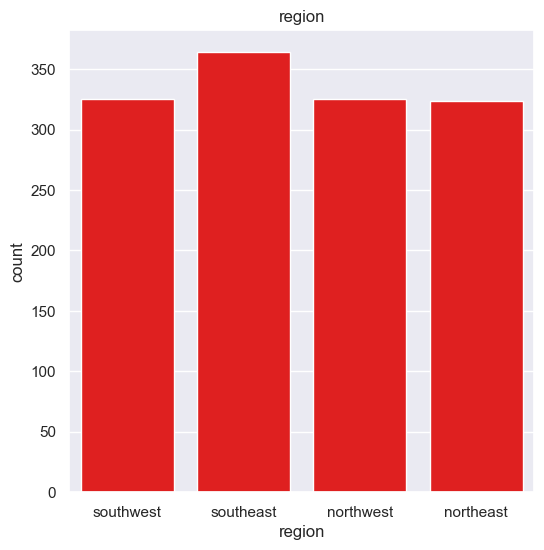

In [10]:
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=df,color='red')
plt.title('region')
plt.show()

In [11]:
df.value_counts('region')

region
southeast    364
northwest    325
southwest    325
northeast    324
Name: count, dtype: int64

In [12]:
df.replace({'sex':{'male':0,'female':1}},inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_12556\209033561.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'sex':{'male':0,'female':1}},inplace=True)


In [13]:
df.replace({'region':{'southwest':0,'northwest':1,'northeast':2,'southeast':3,}},inplace=True)
df.replace({'smoker':{'yes':1,'no':0}},inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_12556\1331632967.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'region':{'southwest':0,'northwest':1,'northeast':2,'southeast':3,}},inplace=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_12556\1331632967.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'smoker':{'yes':1,'no':0}},inplace=True)


In [14]:
x=df.drop('charges',axis=1)
y=df['charges']

In [15]:
print(x,y)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       1       0
1      18    0  33.770         1       0       3
2      28    0  33.000         3       0       3
3      33    0  22.705         0       0       1
4      32    0  28.880         0       0       1
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       0       1
1334   18    1  31.920         0       0       2
1335   18    1  36.850         0       0       3
1336   21    1  25.800         0       0       0
1337   61    1  29.070         0       1       1

[1338 rows x 6 columns] 0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [16]:
x_train,x_test,y_train,y_tets=train_test_split(x,y,test_size=0.2,random_state=2)

In [17]:
print(x_train.shape,x_test.shape,y_tets.shape,y_train.shape)

(1070, 6) (268, 6) (268,) (1070,)


In [18]:
model=LinearRegression()

In [25]:
model.fit(x_train,y_train)

LinearRegression()

In [30]:
y_train_pred=model.predict(x_train)

# use r2 score to dertemine how well regration model explain to depentent variable in based on independent variable

In [31]:
# r squared value
r2_train=r2_score(y_train,y_train_pred)
print('r sqared value:',r2_train)

r sqared value: 0.7512049094405824


In [35]:
y_test_pred=model.predict(x_test)
r2_test=r2_score(y_tets,y_test_pred)
print('r2 score on test data: ',r2_test)

r2 score on test data:  0.7424165105580929


In [20]:
import numpy as np
from sklearn.metrics import r2_score

# 1. Define your actual and predicted data arrays
y_actual = np.array([10, 20, 30, 40, 50])
y_predicted = np.array([12, 18, 33, 38, 51])

# 2. Compute the R-squared score
r2_value = r2_score(y_actual, y_predicted)

print(f"R-squared Score: {r2_value:.3f}")
# Output: R-squared Score: 0.978


R-squared Score: 0.978


In [39]:
#predicting system
input_data=(33,0,22.705,0,0,1)
input_data_as_numy_array=np.asarray(input_data)
input_data_as_resheped=input_data_as_numy_array.reshape(1,-1)
prediction=model.predict(input_data_as_resheped)
print(prediction)

print('the inurace cost is :',prediction)


[3595.46315766]
the inurace cost is : [3595.46315766]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
